In [3]:
import pandas as pd
import numpy as np


df = pd.read_csv('wine.csv')
df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
X = df.iloc[:,1:] #this will returns all our input features
X

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
print(pd.isnull(df).sum());

Class                            0
 Alcohol                         0
 Malic acid                      0
 Ash                             0
 Alcalinity of ash               0
 Magnesium                       0
 Total phenols                   0
 Flavanoids                      0
 Nonflavanoid phenols            0
 Proanthocyanins                 0
 Color intensity                 0
 Hue                             0
 OD280/OD315 of diluted wines    0
 Proline                         0
dtype: int64


In [7]:
#Solution
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler();
X = scaler.fit_transform(X);
X

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [10]:


from sklearn.cluster import KMeans
inertia= [];

K_range = range(1,11);


for k in K_range:
    km = KMeans(n_clusters = k, random_state = 42)
    km. fit(X)
    inertia.append(km.inertia_)

inertia
    

[2314.0,
 1661.6761165626506,
 1277.928488844642,
 1211.7531134671583,
 1123.156547079696,
 1079.538509158826,
 1014.4309086924652,
 982.65497629377,
 927.956076072621,
 879.4257007542494]

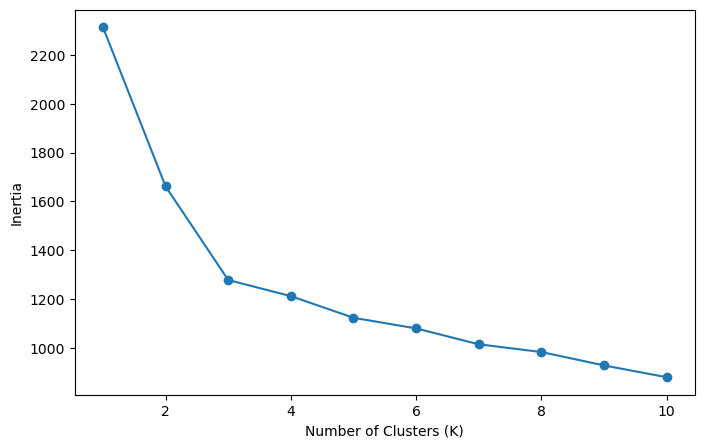

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize =(8,5))
plt.plot(K_range, inertia, marker ='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#inertia = []
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    #inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

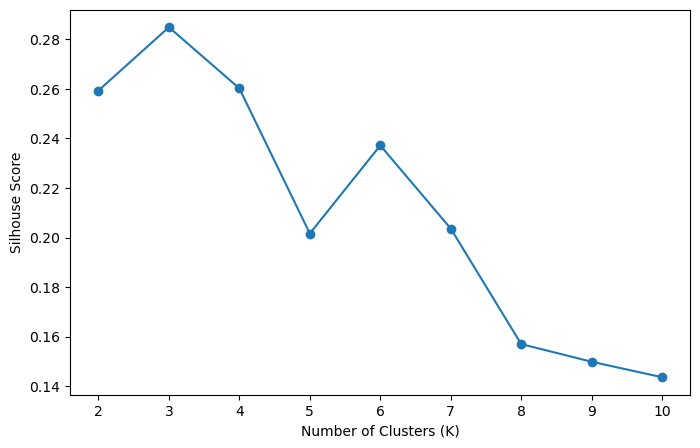

In [34]:

plt.figure(figsize =(8,5))
plt.plot(range(2,11), sil_scores, marker ='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouse Score')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_predict =kmeans.fit_predict(X)

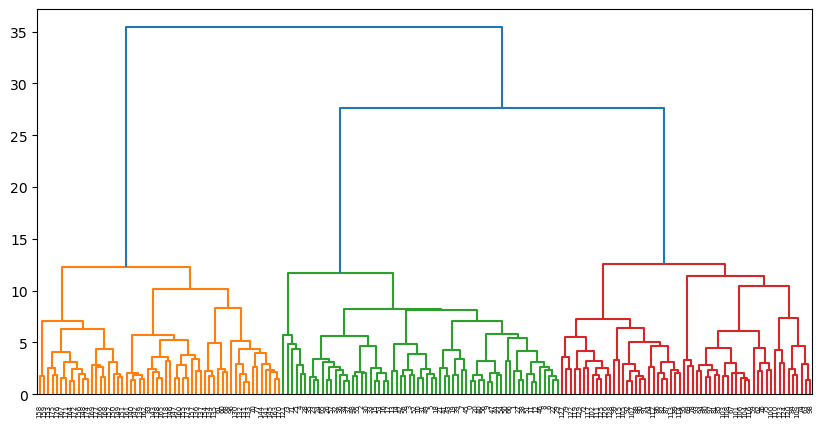

In [20]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.show()


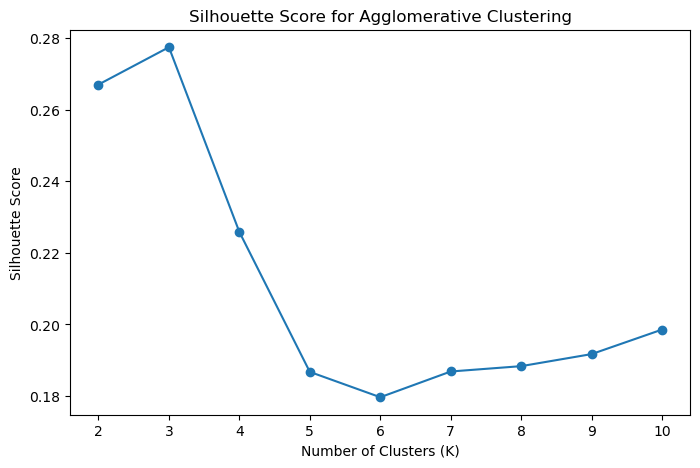

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores2 = []

for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)

    sil_scores2.append(silhouette_score(X, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores2, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Agglomerative Clustering')
plt.show()


In [ ]:
#agg = AgglomerativeClustering(n_clusters=3)
 #   agg_predict = agg.fit_predict(X)

In [33]:
#from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
#PCA inspects the linear relationships between data
#it squiches it in some kind of way


# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=3)
agg_predict = agg.fit_predict(X)

# PCA for visualization / dimensionality reduction
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

#x_pca


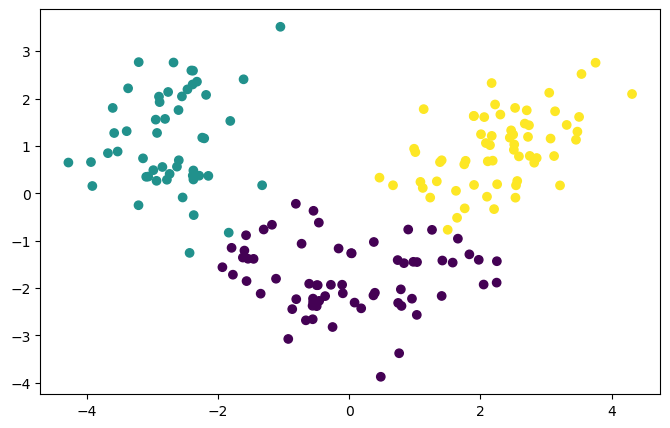

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=kmeans_predict)
plt.show()



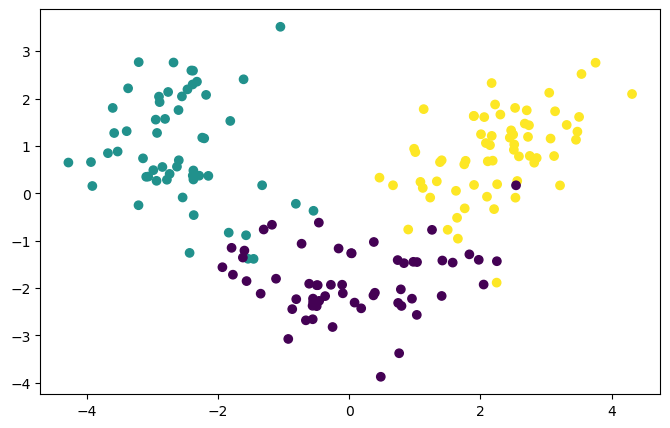

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=agg_predict)
plt.show()

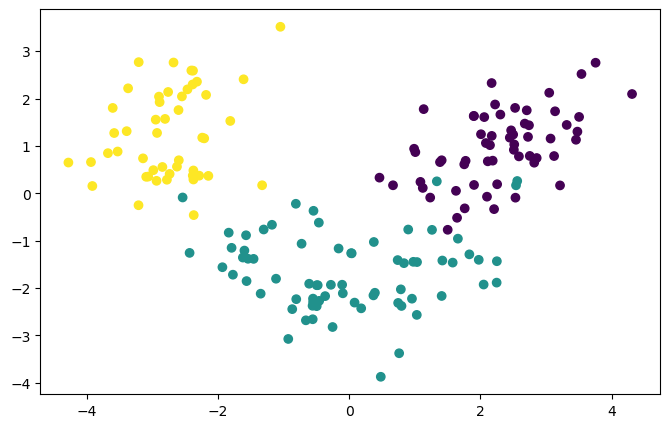

In [30]:
y = df.iloc[:,0]

plt.figure(figsize=(8,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=y)
plt.show()

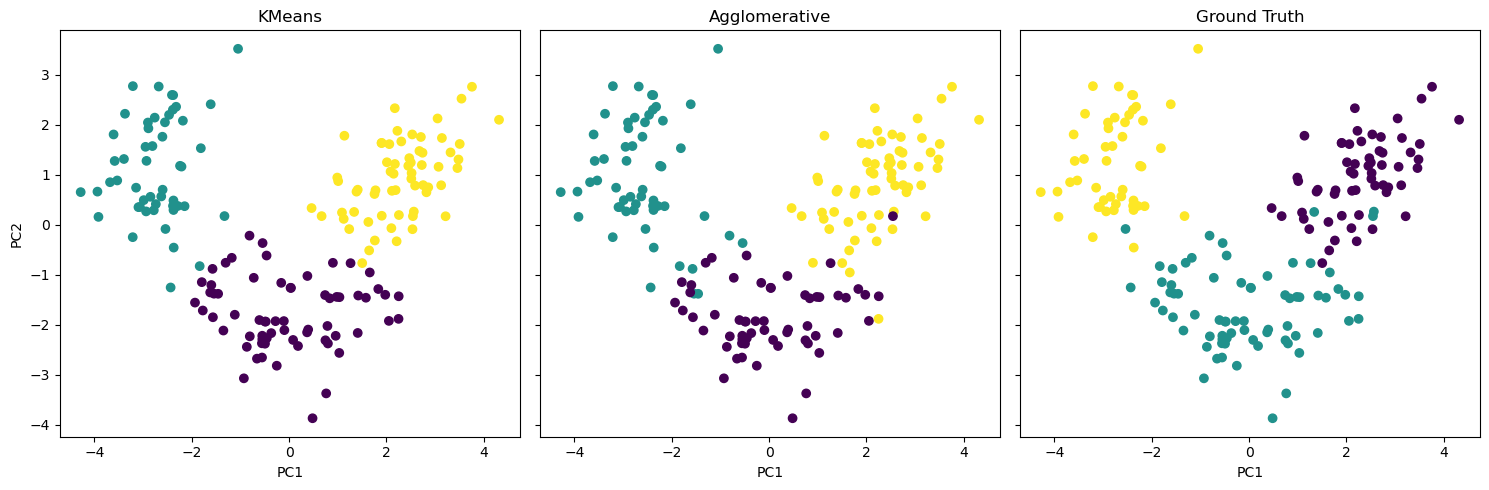

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=kmeans_predict, cmap='viridis')
axes[0].set_title('KMeans')

axes[1].scatter(x_pca[:, 0], x_pca[:, 1], c=agg_predict, cmap='viridis')
axes[1].set_title('Agglomerative')

axes[2].scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='viridis')
axes[2].set_title('Ground Truth')

for ax in axes:
    ax.set_xlabel('PC1')
axes[0].set_ylabel('PC2')

plt.tight_layout()
plt.show()


In [ ]:

#try and apply PCA first and apply the clustering to see if there would be a difference
#or when we try apply dimentionality first befoer applying clustering

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)